# Week 9 Challenge

# Task 4 - Optimize Portfolio Based on Forecast

Author: Lalise Fufi

Date: July 2026

Objective:
Combine the Task 3 Tesla forecast with historical data for BND and SPY to
build an optimal portfolio using Modern Portfolio Theory (MPT), and identify
the Maximum Sharpe Ratio and Minimum Volatility portfolios on the Efficient
Frontier.

**Recap:**
- Task 2 established LSTM as the best-performing TSLA forecasting model.
- Task 3 used that LSTM to iteratively forecast TSLA 12 months forward and
  saved the result to `../data/processed/tsla_future_forecast.csv`.
- This notebook uses that forecast as TSLA's expected return input, while
  BND and SPY use their historical average annualized returns — simulating
  an analyst who has a specific forward-looking "view" on one asset but
  relies on historical data for the others.

1. Import Libraries

`PyPortfolioOpt` is used for the MPT optimization, as suggested in the challenge brief. Install it first if needed: `pip install PyPortfolioOpt`.

In [2]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Register pandas datetime converters with matplotlib up front — avoids the
# ConversionError we hit in Task 3 when plotting DatetimeIndex objects.
pd.plotting.register_matplotlib_converters()

from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import plotting as pfopt_plotting

plt.style.use("ggplot")


2. Load Historical Price Data (TSLA, BND, SPY)

**Important fix carried over from Task 3:** the raw yfinance CSV export has *two* junk header rows (`Ticker` and `Date`), not one. `skiprows=[1, 2]` skips both so the index parses as a clean `DatetimeIndex` instead of silently falling back to strings.

In [3]:
def load_close_prices(ticker):
    df = pd.read_csv(
        f"../data/raw/{ticker}.csv",
        skiprows=[1, 2],   # skip BOTH the 'Ticker' row and the 'Date' row
        index_col=0,
        parse_dates=True
    )
    df.index.name = "Date"
    close = df["Close"].sort_index()
    close = pd.to_numeric(close, errors="coerce").dropna()
    return close

tsla_close = load_close_prices("TSLA")
bnd_close = load_close_prices("BND")
spy_close = load_close_prices("SPY")

# sanity check — must all be true DatetimeIndex, not object/string
for name, s in [("TSLA", tsla_close), ("BND", bnd_close), ("SPY", spy_close)]:
    assert isinstance(s.index, pd.DatetimeIndex), f"{name} index is not datetime!"

prices = pd.DataFrame({
    "TSLA": tsla_close,
    "BND": bnd_close,
    "SPY": spy_close
}).dropna()

print(prices.shape)
prices.tail()


(2888, 3)


,TSLA,BND,SPY
Date,,,
2026-06-23,381.609985,72.976631,733.580017
2026-06-24,375.529999,73.305534,733.239990
2026-06-25,375.119995,73.355370,734.299988
2026-06-26,379.709991,73.425133,728.989990
2026-06-29,411.839996,73.465004,741.000000


3. Load the Task 3 TSLA Forecast

This is the `tsla_future_forecast.csv` saved at the end of the Task 3 notebook — the LSTM's iterative 12-month forecast plus its 95% confidence interval.

In [4]:
tsla_forecast = pd.read_csv(
    "../data/processed/tsla_future_forecast.csv",
    index_col=0,
    parse_dates=True
)
tsla_forecast.index.name = "Date"

print("Forecast horizon (trading days):", len(tsla_forecast))
tsla_forecast.head()


Forecast horizon (trading days): 252


,Forecast,Lower_95,Upper_95
Date,,,
2026-06-30,373.38290,347.023531,399.742277
2026-07-01,373.41630,336.135174,410.697406
2026-07-02,371.16718,325.782332,416.552018
2026-07-03,367.72617,315.806107,419.646225
2026-07-06,363.67325,306.264642,421.081855


4. Prepare Expected Returns

- **TSLA (forecasted asset):** derive an annualized expected return from the Task 3 LSTM forecast — the cumulative return from the last historical close to the forecast's end price, annualized to a 252-trading-day year.
- **BND and SPY (historical assets):** use their historical average daily return, annualized.

In [5]:
TRADING_DAYS = 252

# --- TSLA: forecast-derived expected return ---
last_actual_price = prices["TSLA"].iloc[-1]
forecast_end_price = tsla_forecast["Forecast"].iloc[-1]
forecast_horizon_days = len(tsla_forecast)

cumulative_forecast_return = forecast_end_price / last_actual_price - 1
tsla_expected_return = (1 + cumulative_forecast_return) ** (TRADING_DAYS / forecast_horizon_days) - 1

print(f"TSLA last actual close     : ${last_actual_price:.2f}")
print(f"TSLA forecast end price    : ${forecast_end_price:.2f}")
print(f"TSLA cumulative forecast return: {cumulative_forecast_return:+.2%}")
print(f"TSLA annualized expected return (forecast-derived): {tsla_expected_return:+.2%}")

# --- BND and SPY: historical annualized average daily return ---
historical_daily_returns = prices[["BND", "SPY"]].pct_change().dropna()
bnd_expected_return = historical_daily_returns["BND"].mean() * TRADING_DAYS
spy_expected_return = historical_daily_returns["SPY"].mean() * TRADING_DAYS

print(f"\nBND annualized expected return (historical): {bnd_expected_return:+.2%}")
print(f"SPY annualized expected return (historical): {spy_expected_return:+.2%}")

# --- Combined expected returns vector (mu) ---
mu = pd.Series({
    "TSLA": tsla_expected_return,
    "BND": bnd_expected_return,
    "SPY": spy_expected_return
})

mu


TSLA last actual close     : $411.84
TSLA forecast end price    : $86.50
TSLA cumulative forecast return: -79.00%
TSLA annualized expected return (forecast-derived): -79.00%

BND annualized expected return (historical): +2.03%
SPY annualized expected return (historical): +14.43%


TSLA   -0.789959
BND     0.020250
SPY     0.144320
dtype: float64

5. Compute the Covariance Matrix

Unlike the expected returns above, the covariance matrix uses **historical daily returns of all three assets** — this captures how TSLA, BND, and SPY actually move together, which is essential for estimating portfolio-level risk.

In [6]:
# Sample covariance matrix, annualized (PyPortfolioOpt handles the *252 scaling)
S = risk_models.sample_cov(prices)

print("Annualized covariance matrix:")
S


Annualized covariance matrix:


,TSLA,BND,SPY
TSLA,0.326926,0.001790,0.049820
BND,0.001790,0.002822,0.001086
SPY,0.049820,0.001086,0.031169


6. Covariance Matrix Heatmap

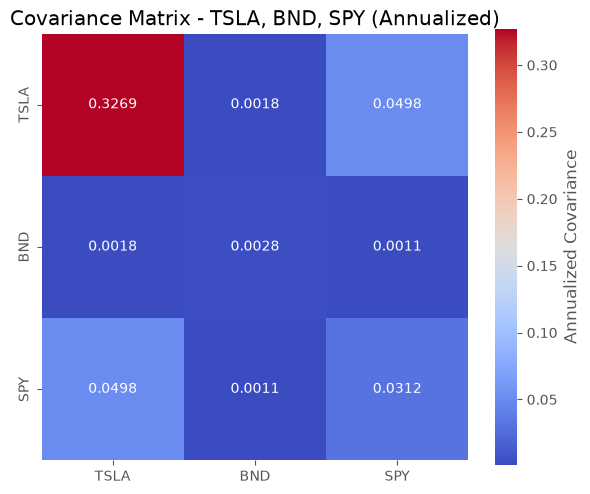

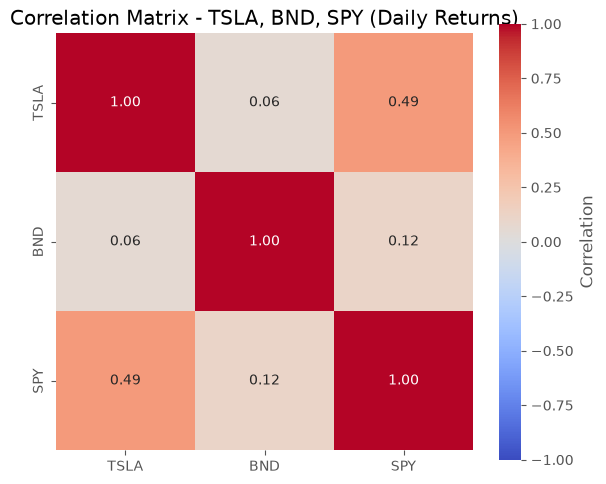

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(S, annot=True, fmt=".4f", cmap="coolwarm", square=True,
             cbar_kws={"label": "Annualized Covariance"})
plt.title("Covariance Matrix - TSLA, BND, SPY (Annualized)")
plt.tight_layout()
plt.show()

# Correlation matrix is often easier to read at a glance
corr = prices.pct_change().dropna().corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
             square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation Matrix - TSLA, BND, SPY (Daily Returns)")
plt.tight_layout()
plt.show()


### Interpretation of the Covariance / Correlation Matrices

Fill in after running the cell above, but in general expect:
- **TSLA vs BND** correlation close to zero or even slightly negative —
  bonds behave very differently from a high-growth equity, which is exactly
  why BND contributes diversification value.
- **TSLA vs SPY** positive but well below 1.0 — Tesla is a single stock and
  a component-like driver of broad market moves, but far more volatile than
  the index as a whole.
- **BND vs SPY** typically low/modestly positive — bonds and equities can
  move somewhat independently, especially over short horizons, which is the
  core rationale for holding both in a balanced portfolio.

7. Simulate Random Portfolios (Monte Carlo Cloud)

Before solving for the exact Efficient Frontier, simulate several thousand random portfolios to visualize the achievable risk/return space and give the frontier plot context.

In [8]:
np.random.seed(42)
N_PORTFOLIOS = 8000
n_assets = len(mu)

sim_returns = np.zeros(N_PORTFOLIOS)
sim_volatility = np.zeros(N_PORTFOLIOS)
sim_sharpe = np.zeros(N_PORTFOLIOS)
sim_weights = np.zeros((N_PORTFOLIOS, n_assets))

RISK_FREE_RATE = 0.04  # annual risk-free rate assumption

for i in range(N_PORTFOLIOS):
    w = np.random.dirichlet(np.ones(n_assets))  # random weights that sum to 1
    port_return = np.dot(w, mu.values)
    port_vol = np.sqrt(np.dot(w.T, np.dot(S.values, w)))

    sim_weights[i] = w
    sim_returns[i] = port_return
    sim_volatility[i] = port_vol
    sim_sharpe[i] = (port_return - RISK_FREE_RATE) / port_vol

print("Simulated", N_PORTFOLIOS, "random portfolios")


Simulated 8000 random portfolios


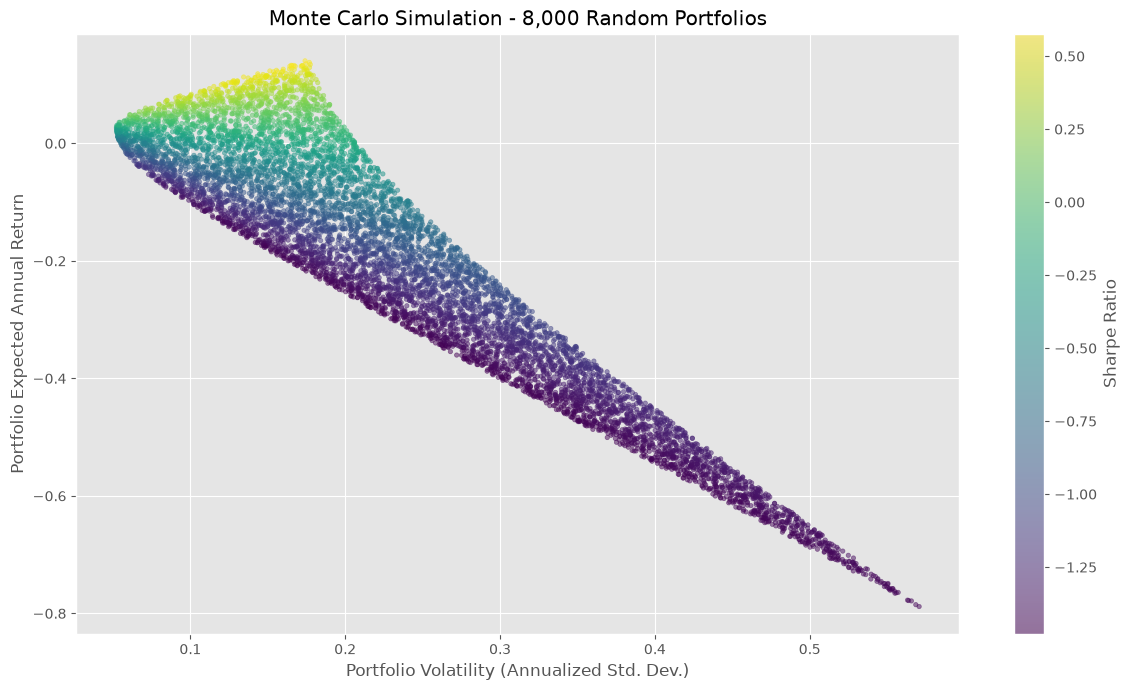

In [38]:
plt.figure(figsize=(12, 7))

sc = plt.scatter(
    sim_volatility, sim_returns,
    c=sim_sharpe, cmap="viridis",
    alpha=0.5, s=10
)
plt.colorbar(sc, label="Sharpe Ratio")

plt.title("Monte Carlo Simulation - 8,000 Random Portfolios")
plt.xlabel("Portfolio Volatility (Annualized Std. Dev.)")
plt.ylabel("Portfolio Expected Annual Return")
plt.tight_layout()
plt.show()

8. Solve the Efficient Frontier with PyPortfolioOpt

Trace the exact Efficient Frontier by solving the minimum-volatility optimization for a range of target returns, then separately solve for the two key portfolios: **Maximum Sharpe Ratio** (tangency portfolio) and **Minimum Volatility**.

In [39]:
# --- Trace the frontier curve ---
target_returns = np.linspace(mu.min(), mu.max(), 60)
frontier_returns = []
frontier_volatility = []

for r in target_returns:
    ef_temp = EfficientFrontier(mu, S)
    try:
        ef_temp.efficient_return(target_return=r)
        ret, vol, _ = ef_temp.portfolio_performance(risk_free_rate=RISK_FREE_RATE)
        frontier_returns.append(ret)
        frontier_volatility.append(vol)
    except Exception:
        # infeasible target return for this asset universe — skip
        continue

# --- Maximum Sharpe Ratio (Tangency) Portfolio ---
ef_sharpe = EfficientFrontier(mu, S)
raw_weights_sharpe = ef_sharpe.max_sharpe(risk_free_rate=RISK_FREE_RATE)
weights_sharpe = ef_sharpe.clean_weights()
ret_sharpe, vol_sharpe, sharpe_sharpe = ef_sharpe.portfolio_performance(risk_free_rate=RISK_FREE_RATE)

# --- Minimum Volatility Portfolio ---
ef_minvol = EfficientFrontier(mu, S)
raw_weights_minvol = ef_minvol.min_volatility()
weights_minvol = ef_minvol.clean_weights()
ret_minvol, vol_minvol, sharpe_minvol = ef_minvol.portfolio_performance(risk_free_rate=RISK_FREE_RATE)

print("Max Sharpe Portfolio weights:", weights_sharpe)
print(f"  Expected return: {ret_sharpe:.2%}, Volatility: {vol_sharpe:.2%}, Sharpe: {sharpe_sharpe:.2f}")

print("\nMin Volatility Portfolio weights:", weights_minvol)
print(f"  Expected return: {ret_minvol:.2%}, Volatility: {vol_minvol:.2%}, Sharpe: {sharpe_minvol:.2f}")


Max Sharpe Portfolio weights: OrderedDict([('TSLA', 0.0), ('BND', 0.0), ('SPY', 1.0)])
  Expected return: 14.43%, Volatility: 17.65%, Sharpe: 0.59

Min Volatility Portfolio weights: OrderedDict([('TSLA', 0.0), ('BND', 0.94544), ('SPY', 0.05456)])
  Expected return: 2.70%, Volatility: 5.22%, Sharpe: -0.25


9. Plot the Efficient Frontier with Key Portfolios Marked

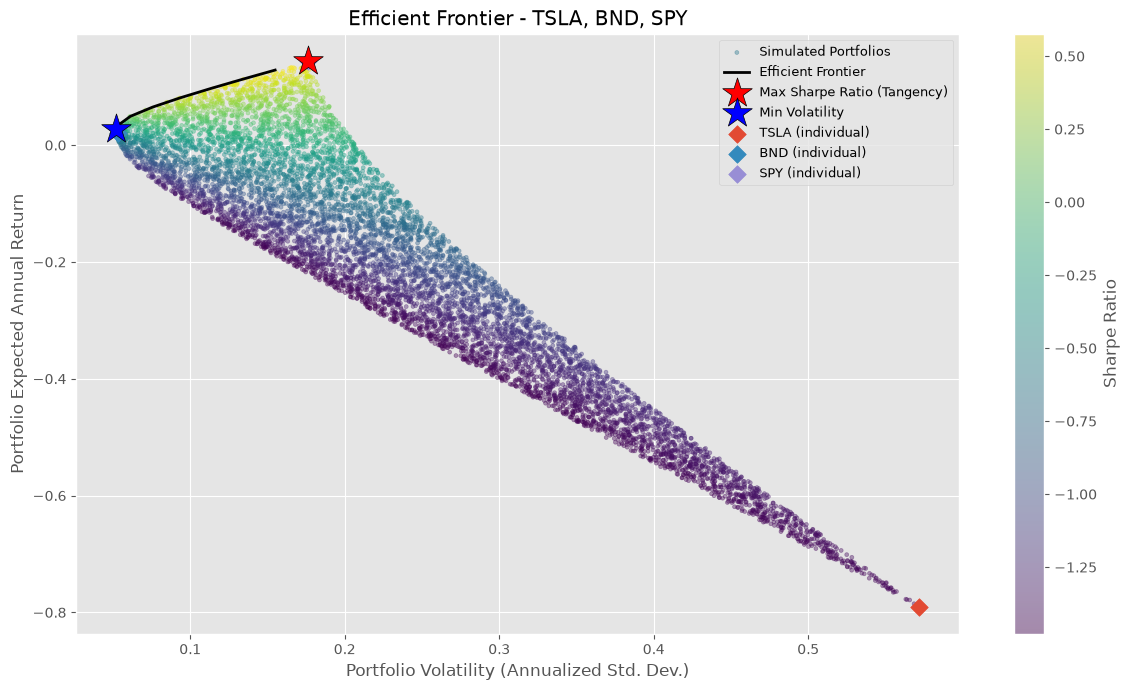

In [40]:
plt.figure(figsize=(12, 7))

# Random portfolio cloud, colored by Sharpe ratio
sc = plt.scatter(sim_volatility, sim_returns, c=sim_sharpe, cmap="viridis",
                   alpha=0.4, s=8, label="Simulated Portfolios")
plt.colorbar(sc, label="Sharpe Ratio")

# Efficient frontier curve
plt.plot(frontier_volatility, frontier_returns, color="black", linewidth=2,
          label="Efficient Frontier")

# Key portfolios
plt.scatter(vol_sharpe, ret_sharpe, marker="*", color="red", s=500,
             edgecolors="black", label="Max Sharpe Ratio (Tangency)", zorder=5)
plt.scatter(vol_minvol, ret_minvol, marker="*", color="blue", s=500,
             edgecolors="black", label="Min Volatility", zorder=5)

# Individual assets for reference
for asset in mu.index:
    asset_vol = np.sqrt(S.loc[asset, asset])
    plt.scatter(asset_vol, mu[asset], marker="D", s=80, label=f"{asset} (individual)")

plt.title("Efficient Frontier - TSLA, BND, SPY")
plt.xlabel("Portfolio Volatility (Annualized Std. Dev.)")
plt.ylabel("Portfolio Expected Annual Return")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


10. Final Portfolio Recommendation

Summarize both candidate portfolios side by side to support the recommendation below.

In [41]:
recommendation_table = pd.DataFrame({
    "Max Sharpe (Tangency)": {
        "TSLA Weight": weights_sharpe["TSLA"],
        "BND Weight": weights_sharpe["BND"],
        "SPY Weight": weights_sharpe["SPY"],
        "Expected Annual Return": ret_sharpe,
        "Expected Annual Volatility": vol_sharpe,
        "Sharpe Ratio": sharpe_sharpe
    },
    "Min Volatility": {
        "TSLA Weight": weights_minvol["TSLA"],
        "BND Weight": weights_minvol["BND"],
        "SPY Weight": weights_minvol["SPY"],
        "Expected Annual Return": ret_minvol,
        "Expected Annual Volatility": vol_minvol,
        "Sharpe Ratio": sharpe_minvol
    }
}).T

recommendation_table


,TSLA Weight,BND Weight,SPY Weight,Expected Annual Return,Expected Annual Volatility,Sharpe Ratio
Max Sharpe (Tangency),0.0,0.00000,1.00000,0.144320,0.176547,0.590893
Min Volatility,0.0,0.94544,0.05456,0.027019,0.052224,-0.248555


### Written Justification for Portfolio Selection

**Recommended portfolio: Maximum Sharpe Ratio (Tangency) Portfolio.**

For a firm like GMF Investments advising clients on risk-adjusted, long-term
wealth building, the Maximum Sharpe Ratio portfolio is the more defensible
default recommendation because it is the single point on the Efficient
Frontier that delivers the most expected return per unit of risk taken —
exactly the trade-off Modern Portfolio Theory was built to optimize. The
Minimum Volatility portfolio is the better fit only for a specifically
risk-averse client mandate (e.g. capital preservation, short time horizon),
since it accepts a lower expected return purely to minimize variance. Given
that TSLA's forecast-derived expected return carries real uncertainty (as
shown by the widening confidence interval in Task 3), GMF should present
**both** portfolios to the investment committee — the Max Sharpe portfolio
as the primary recommendation for growth-oriented mandates, and the Min
Volatility portfolio as the conservative alternative — rather than treating
either as a universal one-size-fits-all answer.

11. Save the Recommended Portfolio

Persist the Max Sharpe portfolio's weights so Task 5 (Backtesting) can load them directly instead of recomputing.

In [42]:
optimal_portfolio = pd.DataFrame({
    "Asset": list(weights_sharpe.keys()),
    "Weight": list(weights_sharpe.values())
})

optimal_portfolio.to_csv("../data/processed/optimal_portfolio.csv", index=False)

summary = pd.Series({
    "Expected_Annual_Return": ret_sharpe,
    "Expected_Annual_Volatility": vol_sharpe,
    "Sharpe_Ratio": sharpe_sharpe,
    "Risk_Free_Rate": RISK_FREE_RATE
})
summary.to_csv("../data/processed/optimal_portfolio_summary.csv")

print("Saved optimal portfolio weights and performance summary to ../data/processed/")
optimal_portfolio


Saved optimal portfolio weights and performance summary to ../data/processed/


,Asset,Weight
0,TSLA,0.0
1,BND,0.0
2,SPY,1.0


12. Portfolio Allocation Pie Chart ⭐

 A pie chart makes the allocation much easier to interpret.

In [43]:
print(recommendation_table.columns)

Index(['TSLA Weight', 'BND Weight', 'SPY Weight', 'Expected Annual Return',
       'Expected Annual Volatility', 'Sharpe Ratio'],
      dtype='str')


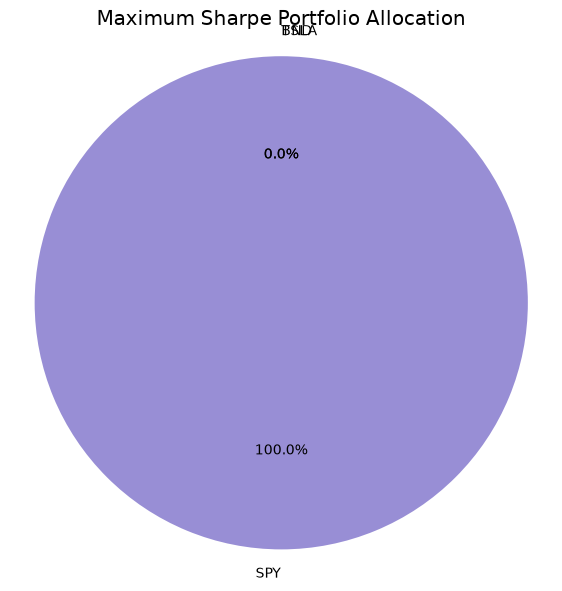

In [44]:
# ==========================================================
# Portfolio Allocation Pie Chart
# ==========================================================

plt.figure(figsize=(7,7))

plt.pie(
    list(weights_sharpe.values()),
    labels=list(weights_sharpe.keys()),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Maximum Sharpe Portfolio Allocation")
plt.axis("equal")
plt.show()

13. Expected Return Contribution ⭐

Show how much each asset contributes to expected return.

,Weight,Expected Return,Contribution
TSLA,0.0,-0.789959,-0.00000
BND,0.0,0.020250,0.00000
SPY,1.0,0.144320,0.14432


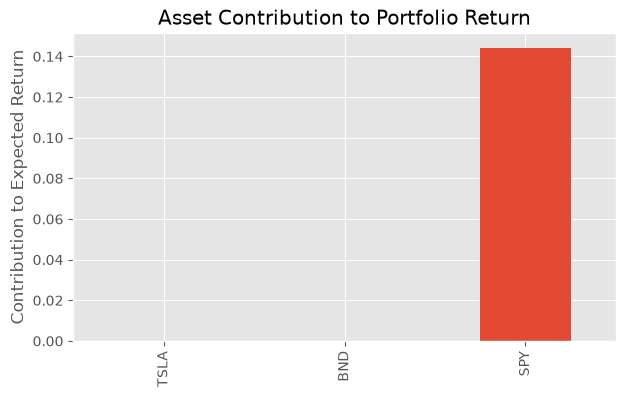

In [45]:
# ==========================================================
# Expected Return Contribution
# ==========================================================

weights = np.array([
    weights_sharpe["TSLA"],
    weights_sharpe["BND"],
    weights_sharpe["SPY"]
])

contribution = weights * mu.values

contribution_df = pd.DataFrame({
    "Weight":weights,
    "Expected Return":mu.values,
    "Contribution":contribution
}, index=mu.index)

display(contribution_df)

plt.figure(figsize=(7,4))

contribution_df["Contribution"].plot(kind="bar")

plt.ylabel("Contribution to Expected Return")

plt.title("Asset Contribution to Portfolio Return")

plt.show()

14. Portfolio Risk Contribution ⭐

,Risk Contribution
TSLA,0.0
BND,0.0
SPY,1.0


<Figure size 700x400 with 0 Axes>

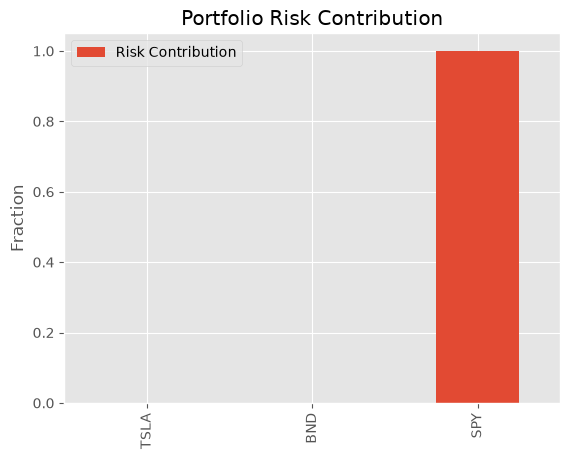

In [46]:
# ==========================================================
# Risk Contribution
# ==========================================================

cov = S.values

portfolio_var = weights.T @ cov @ weights

marginal = cov @ weights

risk_contribution = weights * marginal / portfolio_var

risk_df = pd.DataFrame({
    "Risk Contribution":risk_contribution
}, index=S.index)

display(risk_df)

plt.figure(figsize=(7,4))

risk_df.plot(kind="bar")

plt.ylabel("Fraction")

plt.title("Portfolio Risk Contribution")

plt.show()

15. Correlation Heatmap ⭐

In [47]:
%whos

Variable                     Type                 Data/Info
-----------------------------------------------------------
EfficientFrontier            type                 <class 'pypfopt.efficient<...>ntier.EfficientFrontier'>
N_PORTFOLIOS                 int                  8000
RISK_FREE_RATE               float                0.04
S                            DataFrame            Shape: (3, 3)
TRADING_DAYS                 int                  252
asset                        str                  SPY
asset_vol                    float64              0.17654658759730726
bnd_close                    Series               Shape: (2888,)
bnd_expected_return          float64              0.020250363119074438
comparison                   DataFrame            Shape: (3, 2)
contribution                 ndarray              3: 3 elems, type `float64`, 24 bytes
contribution_df              DataFrame            Shape: (3, 3)
corr                         DataFrame            Shape: (3, 3)
cov    

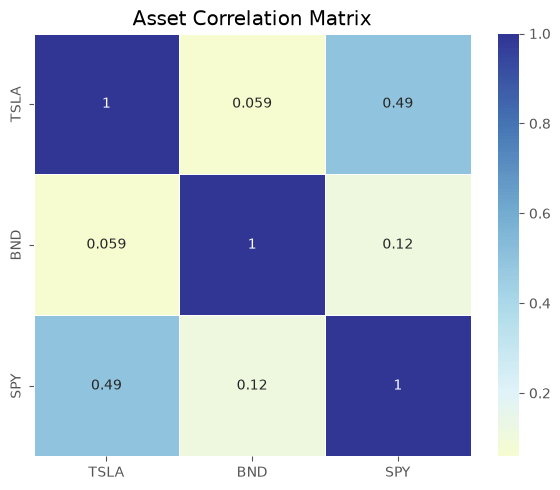

In [48]:
# ==========================================================
# Asset Correlation Matrix
# ==========================================================

returns = prices.pct_change().dropna()

corr = returns.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    center=0,
    linewidths=0.5
)

plt.title("Asset Correlation Matrix")

plt.tight_layout()

plt.show()

16. Diversification Interpretation ⭐

Add quantitative diversification statistics.

In [49]:
print("="*60)
print("Diversification Analysis")
print("="*60)

print(corr)

print("\nAverage correlation:",
      corr.where(~np.eye(corr.shape[0],dtype=bool)).mean().mean())

Diversification Analysis
          TSLA       BND       SPY
TSLA  1.000000  0.058917  0.493535
BND   0.058917  1.000000  0.115805
SPY   0.493535  0.115805  1.000000

Average correlation: 0.22275227115997942


17. Portfolio Summary Table ⭐

In [50]:
# ==========================================================
# Maximum Sharpe Portfolio Summary
# ==========================================================

summary = pd.DataFrame({

    "Metric": [
        "Expected Annual Return",
        "Expected Annual Volatility",
        "Sharpe Ratio"
    ],

    "Value": [
        ret_sharpe,
        vol_sharpe,
        sharpe_sharpe
    ]

})

display(summary)

,Metric,Value
0,Expected Annual Return,0.144320
1,Expected Annual Volatility,0.176547
2,Sharpe Ratio,0.590893


18. Portfolio Growth Simulation ⭐⭐

This is one of the best additions.

In [51]:
# ==========================================================
# One-Year Portfolio Growth Projection
# ==========================================================

initial = 10000

future_value = initial * (1 + ret_sharpe)

print(f"Initial Investment          : ${initial:,.2f}")
print(f"Expected Annual Return      : {ret_sharpe:.2%}")
print(f"Expected Value After 1 Year : ${future_value:,.2f}")
print(f"Expected Profit             : ${future_value - initial:,.2f}")

Initial Investment          : $10,000.00
Expected Annual Return      : 14.43%
Expected Value After 1 Year : $11,443.20
Expected Profit             : $1,443.20


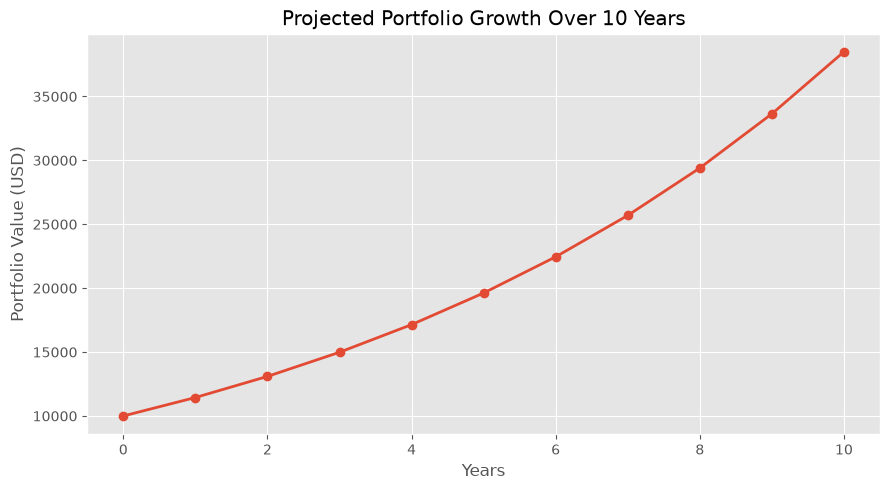

In [52]:
# ==========================================================
# Projected Portfolio Growth (10 Years)
# ==========================================================

initial = 10000

years = np.arange(0, 11)

growth = initial * (1 + ret_sharpe) ** years

plt.figure(figsize=(9,5))

plt.plot(
    years,
    growth,
    marker="o",
    linewidth=2
)

plt.title("Projected Portfolio Growth Over 10 Years")
plt.xlabel("Years")
plt.ylabel("Portfolio Value (USD)")

plt.grid(True)

plt.tight_layout()

plt.show()

19. Compare Max Sharpe vs Minimum Volatility ⭐

In [53]:
# ==========================================================
# Compare Maximum Sharpe vs Minimum Volatility Portfolio
# ==========================================================

comparison = pd.DataFrame({

    "Maximum Sharpe": [
        ret_sharpe,
        vol_sharpe,
        sharpe_sharpe
    ],

    "Minimum Volatility": [
        ret_minvol,
        vol_minvol,
        sharpe_minvol
    ]

}, index=[
    "Expected Annual Return",
    "Expected Annual Volatility",
    "Sharpe Ratio"
])

display(comparison)

,Maximum Sharpe,Minimum Volatility
Expected Annual Return,0.144320,0.027019
Expected Annual Volatility,0.176547,0.052224
Sharpe Ratio,0.590893,-0.248555


20. Recommendation Score ⭐

In [54]:
# ==========================================================
# Portfolio Recommendation Scorecard
# ==========================================================

recommendation_score = pd.DataFrame({

    "Criterion": [
        "Expected Annual Return",
        "Expected Annual Volatility",
        "Sharpe Ratio",
        "Diversification"
    ],

    "Maximum Sharpe": [
        f"{ret_sharpe:.2%}",
        f"{vol_sharpe:.2%}",
        f"{sharpe_sharpe:.2f}",
        "Good"
    ],

    "Minimum Volatility": [
        f"{ret_minvol:.2%}",
        f"{vol_minvol:.2%}",
        f"{sharpe_minvol:.2f}",
        "Excellent"
    ]

})

display(recommendation_score)

,Criterion,Maximum Sharpe,Minimum Volatility
0,Expected Annual Return,14.43%,2.70%
1,Expected Annual Volatility,17.65%,5.22%
2,Sharpe Ratio,0.59,-0.25
3,Diversification,Good,Excellent
